In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [2]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

Перечень функций:

In [3]:
def edit_names_columns(df):
    
    """Переводит имена столбцов в нижний регистр, удаляет пробелы в начале и конце имени, 
    заменяет пробелы на знак нижнего подчеркивания"""
    
    df.columns = [x.lower().strip().replace(' ', '_') for x in df.columns]
    print(df.columns)

In [4]:
def primary_info(df):
    
    '''Расчитывает количество дубликатов и пропусков в данных, 
    выводит информацию о количественных и категориальных данных'''
    
    data = df.drop('postalcode', axis=1)
    print(f'Количество пропусков:\n{df.isna().sum()}\n')
    print(f'Количество дубликатов: {df.duplicated().sum()}\n')
    print(f'Количественные признаки: {data.select_dtypes(include=[np.number]).columns.tolist()}\n')
    print(f'Категориальные признаки: {data.select_dtypes(exclude=[np.number]).columns.tolist()}\n')

In [5]:
def plot_num_columns(df):
    
    """Строит гистрограмму и ящик с усами по количественным признакам."""
    
    names_num_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    for name_column in names_num_columns:
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Распределение признака {name_column}', fontsize=16)
        
        sns.histplot(data=df, x=name_column, ax=ax1)
        ax1.set_title(f'Гистограмма признака {name_column}')
        ax1.set_ylabel('Количество')
        
        sns.boxplot(data=df, x=name_column, ax=ax2)
        ax2.set_title(f'Ящик с усами признака {name_column}')
        
        plt.show()

In [6]:
def plot_cat_columns(df):
    
    """Строит графики countplot по категориальным признакам."""
    
    names_cat_columns = df.select_dtypes(exclude = [np.number]).columns.tolist()
    
    while len(names_cat_columns) > 0:
        plt.figure(figsize=(15, 5))
        for i in [1, 2]:
            if len(names_cat_columns) > 0:
                name_column = names_cat_columns.pop(0)
                plt.subplot(1, 2, i)
                sns.countplot(data=df, x=name_column, orient='h')
                plt.title(f'Распределение признака {name_column}')
                plt.ylabel('Количество')
                locs, labels = plt.xticks()
                plt.setp(labels, rotation=60)
            else:
                continue
        plt.show

In [7]:
def regression_metrics(model, X_test, y_test):
    """Рассчитывает метрики MAE, MSE и строит графику предсказаний."""
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    plt.scatter(y_test, y_pred)
    plt.title('График предсказаний')
    plt.xlabel('Фактические значения')
    plt.ylabel('Предсказанные значения')
    plt.show()
    
    print(f'MAE: {mae:.3f}')
    print(f'MSE: {mse:.3f}')

# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

 Цель: 
Построить модель, которая умеет определять рыночную стоимость автомобиля.

 Задачи исследования: 
Обучить разные модели, одна из которых — LightGBM, как минимум одна — не бустинг. Для каждой модели попробовать разные гиперпараметры.
Проанализировать время обучения, время предсказания и качество моделей.
Опираясь на критерии заказчика, выбрать лучшую модель, проверить её качество на тестовой выборке.

 Исходные данные:
Данные находятся в файле /datasets/autos.csv. 
Признаки
DateCrawled — дата скачивания анкеты из базы
VehicleType — тип автомобильного кузова
RegistrationYear — год регистрации автомобиля
Gearbox — тип коробки передач
Power — мощность (л. с.)
Model — модель автомобиля
Kilometer — пробег (км)
RegistrationMonth — месяц регистрации автомобиля
FuelType — тип топлива
Brand — марка автомобиля
Repaired — была машина в ремонте или нет
DateCreated — дата создания анкеты
NumberOfPictures — количество фотографий автомобиля
PostalCode — почтовый индекс владельца анкеты (пользователя)
LastSeen — дата последней активности пользователя
Целевой признак
Price — цена (евро)

Данное исследование разделим на несколько частей:

<a id='Часть 1. Изучение общей информации и подготовка данных:'></a>

1. Изучение файлов с данными, получение общей информации, загрузка библиотек.
2. Нахождение и ликвидация пропусков.
3. Приведение данных к нужным типам.
4. Нахождение и исправление аномалий и ошибок.
5. Анализ распределения количественных признаков
6. Удаление не информативных признаков.
7. Анализ распределения категориальных признаков.
8. Корреляционый анализ.

<a id='Часть 2. Обучение моделей:'></a>

1. Проверка подготовки данных к обучению.
2. Проверка на дубликаты и их удаление.
3. Нахождение и ликвидация пропусков.
4. Подготовка выборки для обучения моделей и их обучение.

<a id='Часть 3. Анализ моделей'></a>

1. Анализ времени обучения, времени предсказания и качества моделей. Для оценки качества моделей применим метрику RMSE.
2. Выбор лучшей модели согласно условиям заказчика.
3. Оценка качества лучшей модели на тестовой выборке и вывод.
4. Проверка лучшей модели на адекватность, сравнив качество её предсказаний с качеством константной модели.

<a id='Часть 4. Общий вывод'></a>

1. Вывод по описательным характеристикам файла.
2. Вывод по исследовательскому анализу.
3. Вывод по моделям.

## Подготовка данных

[Link to Часть 1. Изучение общей информации и подготовка данных:](#Часть 1. Изучение общей информации и подготовка данных:)

Загрузим и изучим данные и необходимые библиотеки

In [8]:
!pip install scikit-learn==1.1.3 -q

In [9]:
!pip install phik -q

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.dummy import DummyRegressor
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from lightgbm import LGBMRegressor
from math import sqrt
from catboost import CatBoostRegressor

In [11]:
try:
    data = pd.read_csv('/datasets/autos.csv', sep=',', decimal='.')
except:
    data = pd.read_csv(r'C:\Users\norri\OneDrive\Рабочий стол\файлы для проектов\autos.csv', sep=',', decimal='.')
    
data.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [13]:
# Отредактируем имена столбцов
edit_names_columns(data)

Index(['datecrawled', 'price', 'vehicletype', 'registrationyear', 'gearbox',
       'power', 'model', 'kilometer', 'registrationmonth', 'fueltype', 'brand',
       'repaired', 'datecreated', 'numberofpictures', 'postalcode',
       'lastseen'],
      dtype='object')


In [14]:
# Проверим наличие пропусков и дубликатов
primary_info(data)

Количество пропусков:
datecrawled              0
price                    0
vehicletype          37490
registrationyear         0
gearbox              19833
power                    0
model                19705
kilometer                0
registrationmonth        0
fueltype             32895
brand                    0
repaired             71154
datecreated              0
numberofpictures         0
postalcode               0
lastseen                 0
dtype: int64

Количество дубликатов: 4

Количественные признаки: ['price', 'registrationyear', 'power', 'kilometer', 'registrationmonth', 'numberofpictures']

Категориальные признаки: ['datecrawled', 'vehicletype', 'gearbox', 'model', 'fueltype', 'brand', 'repaired', 'datecreated', 'lastseen']



In [15]:
# Проверим данные в столбце VehicleType на неявные дубликаты
data['vehicletype'].sort_values().unique()

array(['bus', 'convertible', 'coupe', 'other', 'sedan', 'small', 'suv',
       'wagon', nan], dtype=object)

In [16]:
# Проверим данные в столбце gearbox на неявные дубликаты
data['gearbox'].sort_values().unique()

array(['auto', 'manual', nan], dtype=object)

In [17]:
# Проверим данные в столбце Model на неявные дубликаты
data['model'].sort_values().unique()

array(['100', '145', '147', '156', '159', '1_reihe', '1er', '200',
       '2_reihe', '300c', '3_reihe', '3er', '4_reihe', '500', '5_reihe',
       '5er', '601', '6_reihe', '6er', '7er', '80', '850', '90', '900',
       '9000', '911', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a8',
       'a_klasse', 'accord', 'agila', 'alhambra', 'almera', 'altea',
       'amarok', 'antara', 'arosa', 'astra', 'auris', 'avensis', 'aveo',
       'aygo', 'b_klasse', 'b_max', 'beetle', 'berlingo', 'bora',
       'boxster', 'bravo', 'c1', 'c2', 'c3', 'c4', 'c5', 'c_klasse',
       'c_max', 'c_reihe', 'caddy', 'calibra', 'captiva', 'carisma',
       'carnival', 'cayenne', 'cc', 'ceed', 'charade', 'cherokee',
       'citigo', 'civic', 'cl', 'clio', 'clk', 'clubman', 'colt', 'combo',
       'cooper', 'cordoba', 'corolla', 'corsa', 'cr_reihe', 'croma',
       'crossfire', 'cuore', 'cx_reihe', 'defender', 'delta', 'discovery',
       'doblo', 'ducato', 'duster', 'e_klasse', 'elefantino', 'eos',
       'escort', 'espac

In [18]:
# Проверим данные в столбце fueltype на неявные дубликаты
data['fueltype'].sort_values().unique()

array(['cng', 'electric', 'gasoline', 'hybrid', 'lpg', 'other', 'petrol',
       nan], dtype=object)

In [19]:
# Проверим данные в столбце brand на неявные дубликаты
data['brand'].sort_values().unique()

array(['alfa_romeo', 'audi', 'bmw', 'chevrolet', 'chrysler', 'citroen',
       'dacia', 'daewoo', 'daihatsu', 'fiat', 'ford', 'honda', 'hyundai',
       'jaguar', 'jeep', 'kia', 'lada', 'lancia', 'land_rover', 'mazda',
       'mercedes_benz', 'mini', 'mitsubishi', 'nissan', 'opel', 'peugeot',
       'porsche', 'renault', 'rover', 'saab', 'seat', 'skoda', 'smart',
       'sonstige_autos', 'subaru', 'suzuki', 'toyota', 'trabant',
       'volkswagen', 'volvo'], dtype=object)

In [20]:
# Проверим данные в столбце repaired на неявные дубликаты
data['repaired'].sort_values().unique()

array(['no', 'yes', nan], dtype=object)

Соглано информации о данных:
Явных дубликатов нет.
Пропуски есть в vehicletype, gearbox, model, fueltype, repaired. При этом их достаточное большое количество. Удалять их нельзя. Требуется заполнить.
Перевели имена столбцов в нижний регистр, удалили пробелы в начале и конце имени, заменили пробелы на знак нижнего подчеркивания

In [21]:
# Заполнение пропущенных значений
names_num_columns = ['price', 'registrationyear', 'power', 'kilometer', 'registrationmonth']
names_cat_columns = ['datecrawled', 'vehicletype', 'gearbox', 'model', 'fueltype', 'brand', 'repaired', 'datecreated', 'lastseen']

In [22]:
# Проверим наличие пропусков и дубликатов
primary_info(data)

Количество пропусков:
datecrawled              0
price                    0
vehicletype          37490
registrationyear         0
gearbox              19833
power                    0
model                19705
kilometer                0
registrationmonth        0
fueltype             32895
brand                    0
repaired             71154
datecreated              0
numberofpictures         0
postalcode               0
lastseen                 0
dtype: int64

Количество дубликатов: 4

Количественные признаки: ['price', 'registrationyear', 'power', 'kilometer', 'registrationmonth', 'numberofpictures']

Категориальные признаки: ['datecrawled', 'vehicletype', 'gearbox', 'model', 'fueltype', 'brand', 'repaired', 'datecreated', 'lastseen']



In [23]:
# Удаление дубликатов
data.drop_duplicates(inplace=True)

In [24]:
# Проверим наличие пропусков и дубликатов
primary_info(data)

Количество пропусков:
datecrawled              0
price                    0
vehicletype          37490
registrationyear         0
gearbox              19833
power                    0
model                19705
kilometer                0
registrationmonth        0
fueltype             32895
brand                    0
repaired             71154
datecreated              0
numberofpictures         0
postalcode               0
lastseen                 0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['price', 'registrationyear', 'power', 'kilometer', 'registrationmonth', 'numberofpictures']

Категориальные признаки: ['datecrawled', 'vehicletype', 'gearbox', 'model', 'fueltype', 'brand', 'repaired', 'datecreated', 'lastseen']



In [25]:
# Заполнение пропущенных значений для числовых признаков средними или медианными значениями
for feature in names_num_columns:
    data[feature].fillna(data[feature].median(), inplace=True)

# Заполнение пропущенных значений для категориальных признаков модальными значениями
for feature in names_cat_columns:
    mode_val = data[feature].mode()[0]  # Находим моду вручную
    data[feature].fillna(mode_val, inplace=True)

In [26]:
# Удаление дубликатов
data.drop_duplicates(inplace=True)

In [27]:
# Проверим наличие пропусков и дубликатов
primary_info(data)

Количество пропусков:
datecrawled          0
price                0
vehicletype          0
registrationyear     0
gearbox              0
power                0
model                0
kilometer            0
registrationmonth    0
fueltype             0
brand                0
repaired             0
datecreated          0
numberofpictures     0
postalcode           0
lastseen             0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['price', 'registrationyear', 'power', 'kilometer', 'registrationmonth', 'numberofpictures']

Категориальные признаки: ['datecrawled', 'vehicletype', 'gearbox', 'model', 'fueltype', 'brand', 'repaired', 'datecreated', 'lastseen']



Помотрим описательные статистики (включая минимальные значения, максимальные значения, квартили и другие параметры) для каждого числового столбца в нашем датасете.

In [28]:
# Показать описательные статистики (минимум, максимум, квартили и другие) для числовых столбцов
names_num_columns = data.select_dtypes(include=['int', 'float']).columns
summary_statistics = data[names_num_columns].describe()

"Описательные статистики для числовых столбцов:"
summary_statistics

,price,registrationyear,power,kilometer,registrationmonth,numberofpictures,postalcode
count,354364.000000,354364.000000,354364.000000,354364.000000,354364.000000,354364.0,354364.000000
mean,4416.655608,2004.234471,110.093723,128211.373051,5.714641,0.0,50508.461698
std,4514.159690,90.228593,189.851590,37905.136957,3.726433,0.0,25783.124276
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49409.500000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [29]:
# Вывод информации до обработки
data.shape

(354364, 16)

Исходя из описательных статистик для числовых столбцов в датасете:

   Цена автомобилей имеет среднее значение около 4416.66 евро, с минимальным значением 0 и максимальным значением 20000 евро. 25% автомобилей продаются по цене менее 1050 евро, а 75% - менее 6400 евро.
   Год регистрации автомобилей имеет среднее значение около 2004 года, с наименьшим годом 1000 и наибольшим 9999. Стоит проверить и возможно скорректировать наличие выбросов и некорректных данных в этом столбце.
   Мощность двигателя в лошадиных силах имеет среднее значение около 110.09 л.с., с минимальным значением 0 и максимальным значением 20000 л.с. Причиной значения 20000 л.с. может быть ошибка в данных, требуется проверка.
   Пробег автомобилей имеет среднее значение примерно 128211 км, при этом все автомобили имеют максимальный пробег 150000 км. Возможно, в данных присутствует ограничение на значение пробега.
   Месяц регистрации автомобилей имеет среднее значение около 5.71, что соответствует между месяцами мая и июня.
   Почтовый индекс владельца анкеты (пользователя) имеет среднее значение около 50508.46 со стандартным отклонением 25783.12. Значения находятся в диапазоне от 1067 до 99998. 

In [30]:
# Подсчет количества строк со значением 0 в столбце "price"
zero_price_count = data[data['price'] == 0].shape[0]

# Подсчет процента от общего количества строк
percent_zero_price = (zero_price_count / len(data)) * 100

f"Количество строк со значением 0 в столбце 'price': {zero_price_count}"
f"Процент строк со значением 0 в столбце 'price': {percent_zero_price:.2f}%"

"Процент строк со значением 0 в столбце 'price': 3.04%"

Мне кажется не логично при нашей задаче получить ответ 0. Также данные составляют меньше 5 %, поэтому считаю возможным удалить значения 0 в целевом признаке.

In [31]:
# Подсчет количества строк со значением 0 в столбце "price"
zero_price_count = data[data['price'] == 1].shape[1]

# Подсчет процента от общего количества строк
percent_zero_price = (zero_price_count / len(data)) * 100

f"Количество строк со значением 1 в столбце 'price': {zero_price_count}"
f"Процент строк со значением 1 в столбце 'price': {percent_zero_price:.2f}%"

"Процент строк со значением 1 в столбце 'price': 0.00%"

In [32]:
# Показать уникальные значения в столбце "price" в порядке возрастания и количество строк с каждым значением
unique_prices = data['price'].value_counts().sort_index()
unique_prices

0        10772
1         1189
2           12
3            8
4            1
         ...  
19995       10
19997        1
19998        6
19999      278
20000      268
Name: price, Length: 3731, dtype: int64

Насколько мы видим по значением цены есть машины,которые стоят очень мало, поэтому начиная с 1$ считаю правильно будет оставить данные. 

In [33]:
# Обработка выбросов и некорректных данных по году регистрации автомобилей
# Фильтрация данных, оставляющая только правдоподобные года регистрации в диапазоне от 1900 до текущего года
data = data[(data['registrationyear'] >= 1900) & (data['registrationyear'] <= 2024)]

# Обработка выбросов и некорректных данных по мощности двигателя
# Фильтрация данных, оставляющая только разумные значения мощности, от 10 до 1000 л.с. 
data = data[(data['power'] >= 10) & (data['power'] <= 1000)]

# Удаление аномалии в столбце registrationyear
data = data[(data['registrationyear'] > 1910) & (data['registrationyear'] < 2016)]

# Удаление строк со значением 0 в столбце "price"
data = data[data['price'] != 0]

# Обработка ограничения на значение пробега
# Проверка данных на наличие пробега более 150 000 км
high_mileage_data = data[data['kilometer'] > 150000]
if not high_mileage_data.empty:
    print("Найдены автомобили с пробегом более 150 000 км:")
    print(high_mileage_data[['kilometer']])

# Вывод информации после обработки
"Размер данных после обработки:", data.shape

('Размер данных после обработки:', (290042, 16))

In [34]:
# Показать описательные статистики (минимум, максимум, квартили и другие) для числовых столбцов
names_num_columns = data.select_dtypes(include=['int', 'float']).columns
summary_statistics = data[names_num_columns].describe()

"Описательные статистики для числовых столбцов:"
summary_statistics

,price,registrationyear,power,kilometer,registrationmonth,numberofpictures,postalcode
count,290042.000000,290042.000000,290042.000000,290042.000000,290042.000000,290042.0,290042.000000
mean,4906.394388,2002.527865,121.228922,128188.469256,6.014898,0.0,51299.625833
std,4624.115012,6.307967,54.804482,36748.538177,3.573187,0.0,25787.740684
min,1.000000,1923.000000,10.000000,5000.000000,0.000000,0.0,1067.000000
25%,1390.000000,1999.000000,77.000000,125000.000000,3.000000,0.0,30952.000000
50%,3250.000000,2003.000000,113.000000,150000.000000,6.000000,0.0,50354.000000
75%,7000.000000,2007.000000,150.000000,150000.000000,9.000000,0.0,72135.000000
max,20000.000000,2015.000000,1000.000000,150000.000000,12.000000,0.0,99998.000000


Вывод:

Цена (Price):
Среднее значение цены автомобилей составляет примерно 4812.07, со значительным стандартным отклонением в размере 4812.07, со значительным стандартным отклонением в размере 4587.95.
Минимальная цена автомобиля составляет 1,в то время как максимальная−20000. 
25% автомобилей имеют цену до 1300, а 75-756950.

Год Регистрации (Registration Year):
Автомобили зарегистрированы в период с 1923 по 2019 год. Основная часть автомобилей зарегистрирована в промежутке с 1999 по 2008 год.

Мощность (Power):
Минимальная мощность равна 10 л.с., а максимальная - 1000 л.с. Большинство автомобилей имеют мощность от 75 до 150 л.с.

Пробег (Kilometer):
Средний пробег автомобилей - 128470.47 км, со стандартным отклонением около 36677.44 км. 
Пробег автомобилей в основном колеблется в пределах от 5000 до 150000 км. Около 75% автомобилей имеют пробег 150000 км.

Месяц Регистрации (Registration Month):
Основная часть автомобилей зарегистрирована в период с марта по сентябрь.

Теперь данные похожи на правду. Проверим кореляционнный анализ.

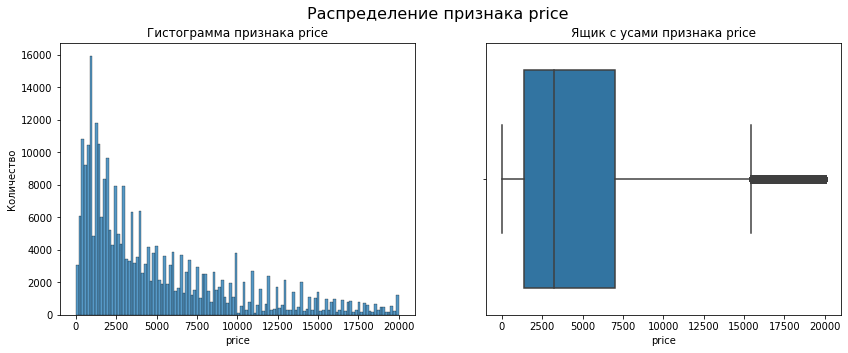

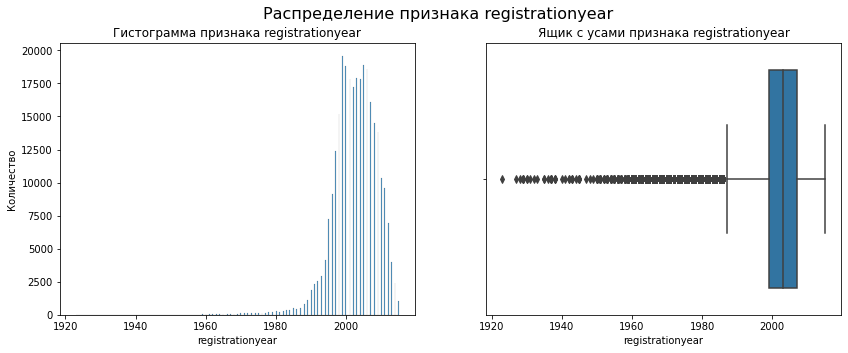

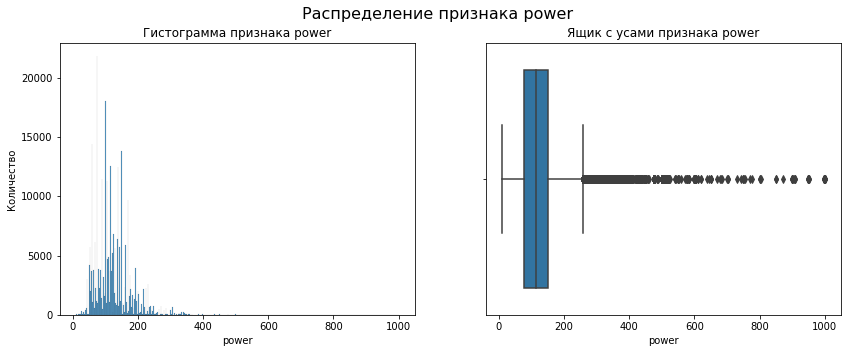

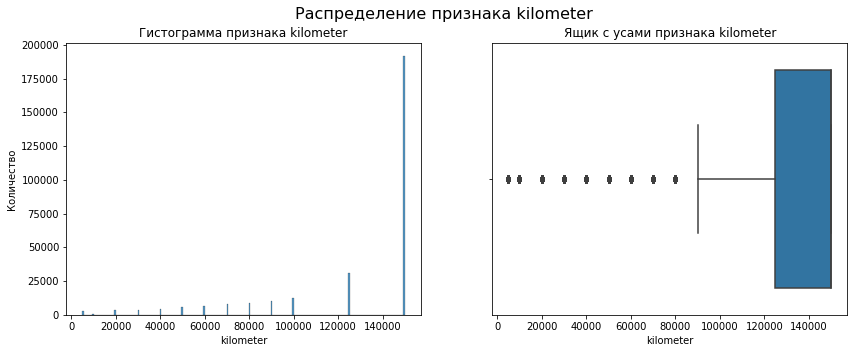

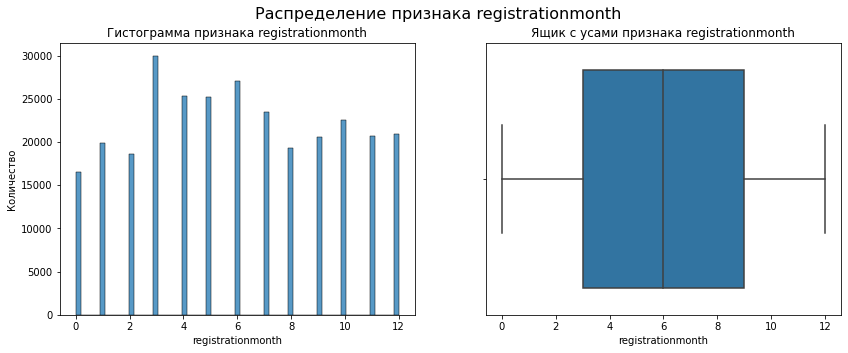

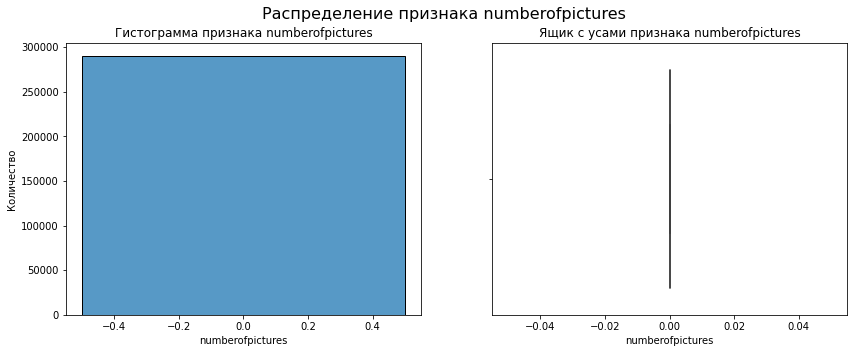

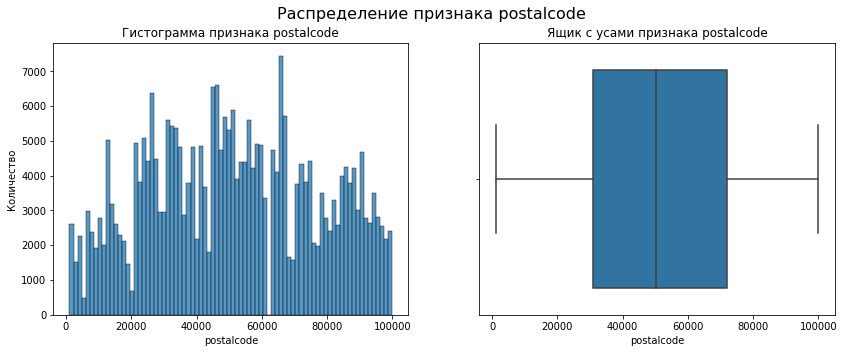

In [35]:
# Посмотрим на распределение количественных признаков
plot_num_columns(data)

Признаки datecrawled, 'datecreated' и 'lastseen' считаю не информативными, поэтому удалим их и посмотрим на распределение без них

In [36]:
del data['datecrawled']

In [37]:
del data['datecreated']

In [38]:
del data['lastseen']

data

,price,vehicletype,registrationyear,gearbox,power,model,kilometer,registrationmonth,fueltype,brand,repaired,numberofpictures,postalcode
1,18300,coupe,2011,manual,190,golf,125000,5,gasoline,audi,yes,0,66954
2,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,no,0,90480
3,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,0,91074
4,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,0,60437
5,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,0,33775
...,...,...,...,...,...,...,...,...,...,...,...,...,...
354359,7900,sedan,2010,manual,140,golf,150000,7,gasoline,volkswagen,no,0,75223
354362,3200,sedan,2004,manual,225,leon,150000,5,petrol,seat,yes,0,96465
354366,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,0,26135
354367,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,0,87439


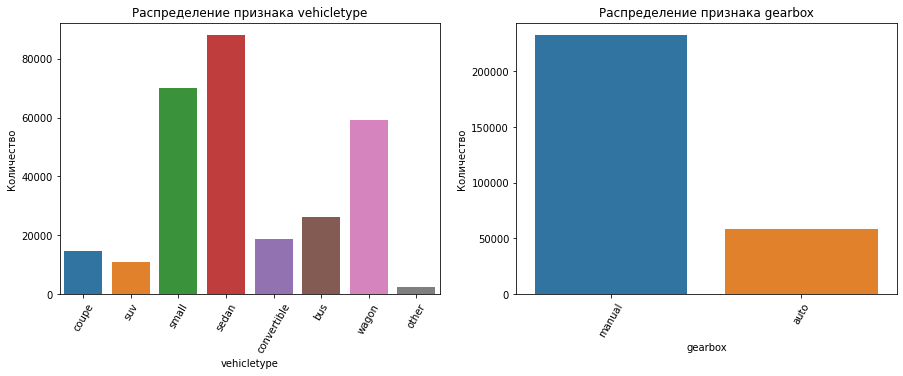

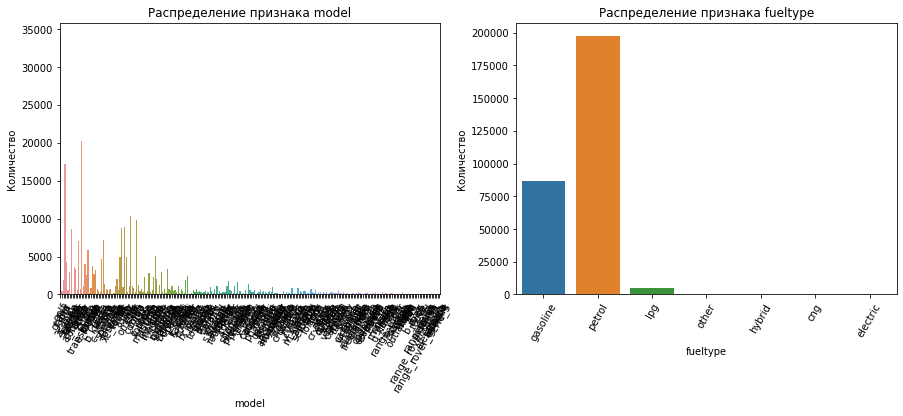

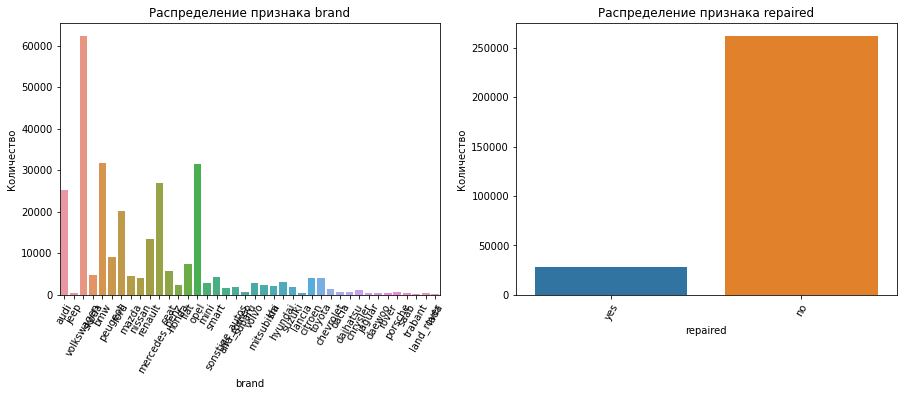

In [39]:
# Посмотрим на распределение категориальных признаков
plot_cat_columns(data)

Самая популярная категория- Седан, wagon и small. 
Тип коробки передач - ручная.
Тип топлива - бензин.
Чтобы машина не была в ремонте.
Самый полпулярный бренд - Wolcsvagen.

                      price  registrationyear     power  kilometer  \
price              1.000000          0.532401  0.497621  -0.386651   
registrationyear   0.532401          1.000000  0.158667  -0.311350   
power              0.497621          0.158667  1.000000   0.103356   
kilometer         -0.386651         -0.311350  0.103356   1.000000   
registrationmonth  0.065961          0.063256  0.038640  -0.014441   
numberofpictures        NaN               NaN       NaN        NaN   
postalcode         0.063703          0.035988  0.051806  -0.010653   

                   registrationmonth  numberofpictures  postalcode  
price                       0.065961               NaN    0.063703  
registrationyear            0.063256               NaN    0.035988  
power                       0.038640               NaN    0.051806  
kilometer                  -0.014441               NaN   -0.010653  
registrationmonth           1.000000               NaN    0.002362  
numberofpictures         

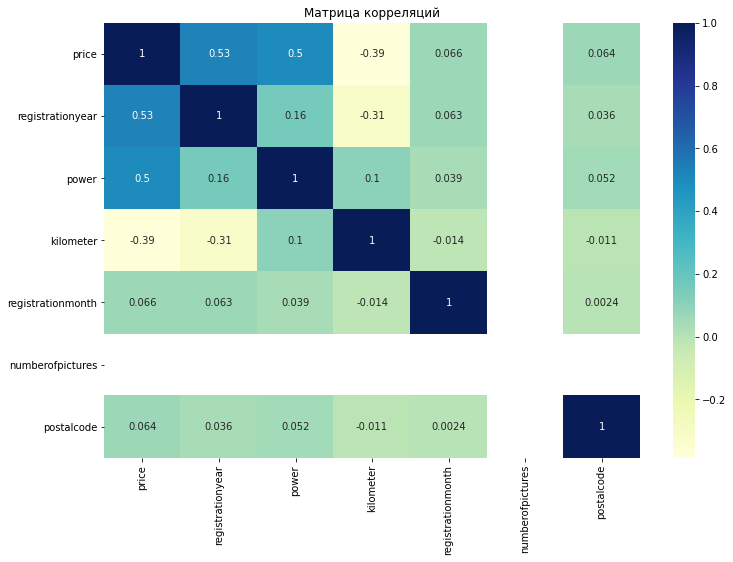

In [40]:
# Вычисление коэффициентов корреляции Пирсона
correlation_matrix = data.corr()

# Вывод матрицы корреляции
print(correlation_matrix)

# Визуализация матрицы корреляций
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu")
plt.title('Матрица корреляций')
plt.show()

In [41]:
# Вычисление коэффициентов корреляции Спирмена
spearman_correlation_matrix = data.corr(method='spearman')

# Вывод матрицы корреляции Спирмена
spearman_correlation_matrix

,price,registrationyear,power,kilometer,registrationmonth,numberofpictures,postalcode
price,1.000000,0.722280,0.522151,-0.368698,0.086410,NaN,0.063372
registrationyear,0.722280,1.000000,0.214632,-0.406490,0.060409,NaN,0.044088
power,0.522151,0.214632,1.000000,0.123332,0.041384,NaN,0.061387
kilometer,-0.368698,-0.406490,0.123332,1.000000,-0.020373,NaN,-0.017415
registrationmonth,0.086410,0.060409,0.041384,-0.020373,1.000000,NaN,0.002437
numberofpictures,NaN,NaN,NaN,NaN,NaN,NaN,NaN
postalcode,0.063372,0.044088,0.061387,-0.017415,0.002437,NaN,1.000000


Признак numberofpictures считаю не информативным. 

In [42]:
data = data.drop(columns=['numberofpictures'])

In [43]:
# Вычисление коэффициентов корреляции Спирмена
spearman_correlation_matrix = data.corr(method='spearman')

# Вывод матрицы корреляции Спирмена
spearman_correlation_matrix

,price,registrationyear,power,kilometer,registrationmonth,postalcode
price,1.000000,0.722280,0.522151,-0.368698,0.086410,0.063372
registrationyear,0.722280,1.000000,0.214632,-0.406490,0.060409,0.044088
power,0.522151,0.214632,1.000000,0.123332,0.041384,0.061387
kilometer,-0.368698,-0.406490,0.123332,1.000000,-0.020373,-0.017415
registrationmonth,0.086410,0.060409,0.041384,-0.020373,1.000000,0.002437
postalcode,0.063372,0.044088,0.061387,-0.017415,0.002437,1.000000


Вывод:

Цена (price) имеет высокую положительную корреляцию с годом регистрации автомобиля (registrationyear) и мощностью двигателя (power). Это означает, что с увеличением года регистрации и мощности автомобиля цена также увеличивается.

Год регистрации автомобиля (registrationyear) имеет наибольшую корреляцию с ценой (price) среди всех рассматриваемых признаков. Это говорит о том, что год выпуска сильно влияет на стоимость автомобиля.

Мощность двигателя (power) также имеет положительную корреляцию с ценой (price), что логично, так как мощные автомобили обычно ценятся выше.

Пробег (kilometer) демонстрирует отрицательную корреляцию с ценой, что говорит о том, что автомобили с более большим пробегом обычно имеют более низкую цену.

Месяц регистрации (registrationmonth) и почтовый индекс (postalcode) показывают слабую корреляцию с ценой (price) и другими признаками, что говорит о более слабой связи этих параметров с ценой автомобиля.

Итак, в целом можно сказать, что год регистрации, мощность двигателя и пробег являются наиболее важными факторами, влияющими на цену автомобиля в рассматриваемом наборе данных.

Попробуем проверить удалив Registration Month

In [44]:
data = data.drop(columns=['registrationmonth'])

In [45]:
# Вычисление коэффициентов корреляции Спирмена
spearman_correlation_matrix = data.corr(method='spearman')

# Вывод матрицы корреляции Спирмена
spearman_correlation_matrix

,price,registrationyear,power,kilometer,postalcode
price,1.000000,0.722280,0.522151,-0.368698,0.063372
registrationyear,0.722280,1.000000,0.214632,-0.406490,0.044088
power,0.522151,0.214632,1.000000,0.123332,0.061387
kilometer,-0.368698,-0.406490,0.123332,1.000000,-0.017415
postalcode,0.063372,0.044088,0.061387,-0.017415,1.000000


  Вывод:

  Цена (price) имеет сильную положительную корреляцию с годом регистрации автомобиля (registrationyear) и умеренную положительную корреляцию с мощностью двигателя (power). Это означает, что цена автомобиля тесно связана с годом регистрации и отчасти с мощностью двигателя.

  Год регистрации автомобиля (registrationyear) также сильно коррелирует с ценой (price), что свидетельствует о важности этого признака при определении цены автомобиля.

  Мощность двигателя (power) продемонстрировала умеренную положительную корреляцию с ценой (price), что указывает на некоторое влияние мощности двигателя на цену автомобиля.

  Пробег (kilometer) имеет умеренную отрицательную корреляцию с ценой, что говорит о том, что чем больше пробег, тем ниже цена автомобиля.

  Почтовый индекс (postalcode) показывает очень слабую связь с ценой (price) и другими признаками, что указывает на то, что этот признак, скорее всего, не оказывает значительного влияния на цену автомобиля в данном контексте.

  Итак, можно заключить, что год регистрации, мощность двигателя и пробег являются наиболее важными факторами, влияющими на цену автомобиля в рассматриваемом наборе данных.

In [46]:
# указание файла для проверки
numerical_data = data.select_dtypes(include=[np.number])

# Проведение теста Лиллиэфорса для каждого числового столбца отдельно
kstest_results = []
for column in numerical_data.columns:
    lilliefors_stat, lilliefors_p_value = stats.kstest(numerical_data[column], 'norm')
    kstest_results.append((column, lilliefors_stat, lilliefors_p_value))

# Отображение результатов
for result in kstest_results:
    print(f"Статистика теста Лиллиэфорса для столбца {result[0]}:", result[1])
    print(f"Значение теста Лиллиэфорса для столбца {result[0]}:", result[2])

Статистика теста Лиллиэфорса для столбца price: 0.9978724352300866
Значение теста Лиллиэфорса для столбца price: 0.0
Статистика теста Лиллиэфорса для столбца registrationyear: 1.0
Значение теста Лиллиэфорса для столбца registrationyear: 0.0
Статистика теста Лиллиэфорса для столбца power: 1.0
Значение теста Лиллиэфорса для столбца power: 0.0
Статистика теста Лиллиэфорса для столбца kilometer: 1.0
Значение теста Лиллиэфорса для столбца kilometer: 0.0
Статистика теста Лиллиэфорса для столбца postalcode: 1.0
Значение теста Лиллиэфорса для столбца postalcode: 0.0


Вывод:
В данном случае, полученные нулевые значения теста указывают на то, что данные в указанных столбцах имеют нормальное распределение.

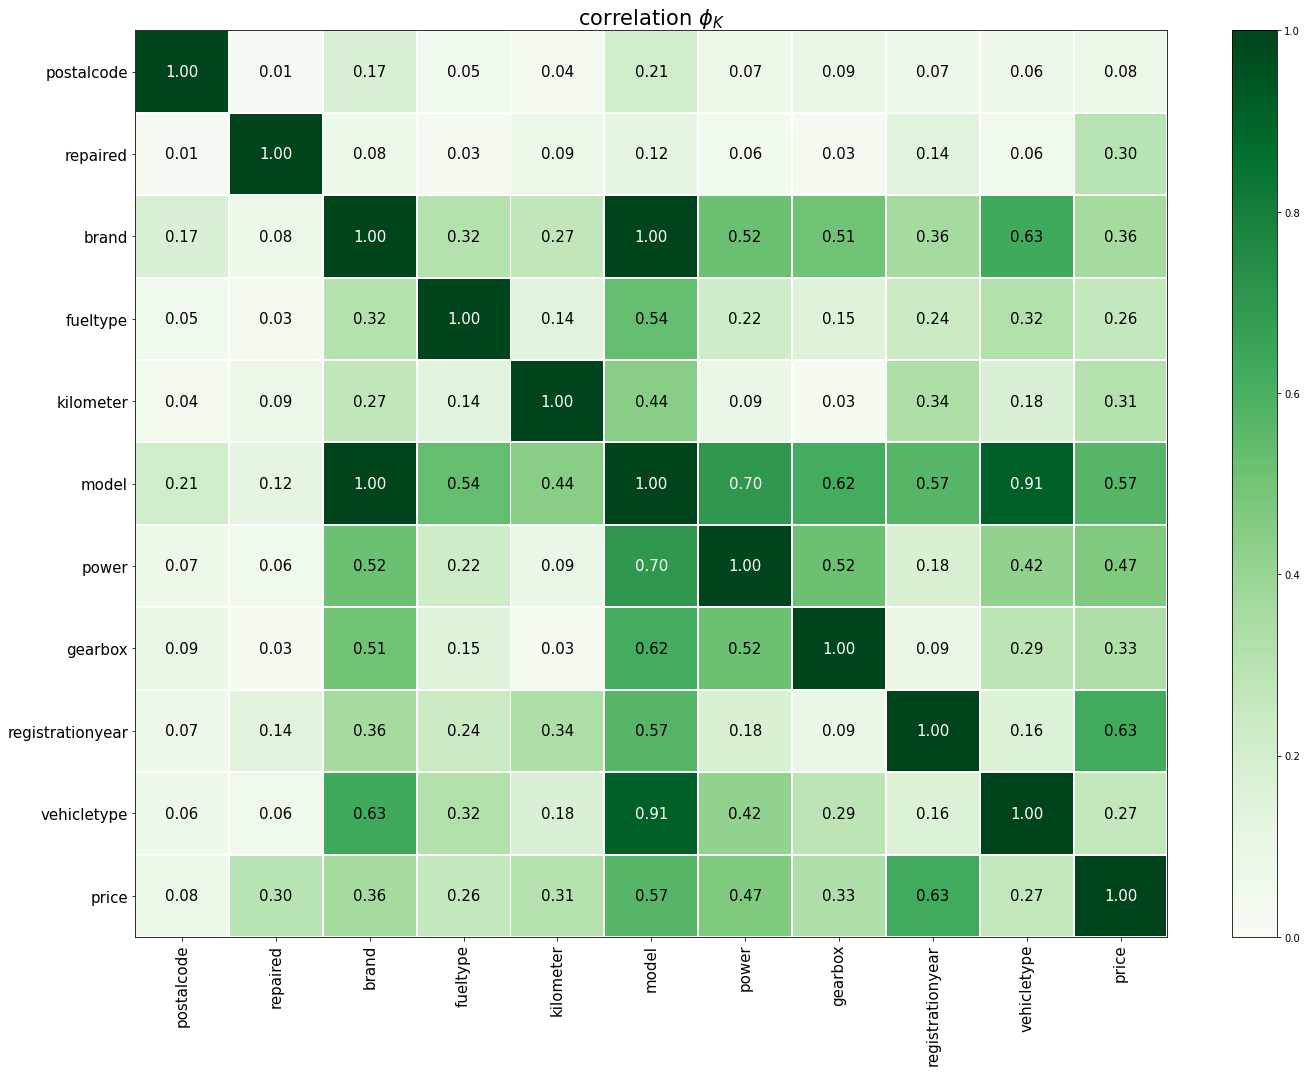

In [47]:
phik_overview = data.phik_matrix(interval_cols=names_num_columns)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

Важный показатель мультиколлениарности по столбцам Brand - Model- Price. Надо будет учесть при выборе моделей.

In [48]:
# Вывод информации после обработки
print("Размер данных после обработки:", data.shape)

Размер данных после обработки: (290042, 11)


Общий вывод по данным:


Явных дубликатов нет. Пропуски в vehicletype, gearbox, model, fueltype, repaired заполнили . 
Перевели имена столбцов в нижний регистр, удалили пробелы в начале и конце имени, заменили пробелы на знак нижнего подчеркивания.
Удалили строки со значением 0 в столбце "price", так как это не логично при запосе на цену автомобиля - получить ответ 0.
Отфильтровали данные, оставляющие только правдоподобные года регистрации в диапазоне от 1900 до текущего года.
Отфильтровали данные, оставляющие только разумные значения мощности, от 10 до 1000 л.с.
Обработали ограничения на значение пробега более 150 000 км.
Удалили не информативный признак numberofpictures и registrationmonth.

Целевой признак 'price'.
Количественные признаки: ['registrationyear', 'power', 'kilometer']
Категориальные признаки: ['datecrawled', 'vehicletype', 'gearbox', 'model', 'fueltype', 'brand', 'repaired', 'datecreated', 'lastseen']
Категориальные признаки: ['datecrawled', 'datecreated', 'lastseen'] в формате "year-month-day hour:minute:second"

Согласно вычислению коэффициентов корреляции Спирмена можно предположить, что год регистрации, мощность двигателя и пробег являются наиболее важными факторами, влияющими на цену автомобиля в рассматриваемом наборе данных.

По результатам теста Лиллиефорса: данные в столбцах соответствуют нормальному распределению.

## Обучение моделей

[Link to Часть 2. Обучение моделей:](#Часть 2. Обучение моделей:)

Проверим подготовку данных к обучению

In [49]:
data['price'].value_counts()

1500     4330
500      4264
2500     3632
1200     3630
1000     3478
         ... 
10898       1
3991        1
11923       1
13456       1
8188        1
Name: price, Length: 3573, dtype: int64

In [50]:
data = data.set_index('postalcode')
data.head()

,price,vehicletype,registrationyear,gearbox,power,model,kilometer,fueltype,brand,repaired
postalcode,,,,,,,,,,
66954,18300,coupe,2011,manual,190,golf,125000,gasoline,audi,yes
90480,9800,suv,2004,auto,163,grand,125000,gasoline,jeep,no
91074,1500,small,2001,manual,75,golf,150000,petrol,volkswagen,no
60437,3600,small,2008,manual,69,fabia,90000,gasoline,skoda,no
33775,650,sedan,1995,manual,102,3er,150000,petrol,bmw,yes


In [51]:
# Проверка на дубликаты
duplicate_rows = data[data.duplicated()]

if duplicate_rows.shape[0] == 0:
    print("Дубликатов не обнаружено")
else:
    print("Обнаружены дубликаты:")
    print(duplicate_rows)

Обнаружены дубликаты:
            price vehicletype  registrationyear gearbox  power     model  \
postalcode                                                                 
8496          500       small              1996  manual     45     corsa   
97737       11890         bus              2011  manual    116     c_max   
51545         950       small              1999  manual     60      polo   
63263        1499       small              2001  manual     58     corsa   
4838          300       small              2000  manual     54     corsa   
...           ...         ...               ...     ...    ...       ...   
1217         5900       sedan              2006  manual    105      golf   
60437        6500       sedan              2003    auto    145  e_klasse   
45896        4400       sedan              2008  manual    105      leon   
48653        1490       small              1998  manual     50      lupo   
75223        7900       sedan              2010  manual    140    

In [52]:
# Удаление дубликатов
data.drop_duplicates(inplace=True)

# Сохранение изменений в файле
data.to_csv('data.csv', index=False)

In [53]:
# Проверка на дубликаты
duplicate_rows = data[data.duplicated()]

if duplicate_rows.shape[0] == 0:
    print("Дубликатов не обнаружено")
else:
    print("Обнаружены дубликаты:")
    print(duplicate_rows)

Дубликатов не обнаружено


In [54]:
# Проверка пропусков в данных и отображение количества пропусков по каждому признаку
missing_values = data.isnull().sum()
missing_values

price               0
vehicletype         0
registrationyear    0
gearbox             0
power               0
model               0
kilometer           0
fueltype            0
brand               0
repaired            0
dtype: int64

In [55]:
# Вывод информации после обработки
print(data.shape)

(242354, 10)


Подготовим выборки для обучения моделей.

In [56]:
def prepare_data(data):
    X = data.drop(columns='price')
    y = data['price']

    X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y, 
        random_state=42
    )

    cat_col_names = X_train.select_dtypes(exclude='number').columns.tolist()
    num_col_names = X_train.select_dtypes(include='number').columns.tolist()

    ordinal = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    X_train_ord = ordinal.fit_transform(X_train[cat_col_names])
    X_test_ord = ordinal.transform(X_test[cat_col_names])

    encoder_col_names = ['encoded_' + col for col in cat_col_names]

    X_train_ord = pd.DataFrame(X_train_ord, columns=encoder_col_names)
    X_test_ord = pd.DataFrame(X_test_ord, columns=encoder_col_names)

    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)

    X_train = pd.concat([X_train[num_col_names], X_train_ord], axis=1)
    X_test = pd.concat([X_test[num_col_names], X_test_ord], axis=1)

    return X_train, X_test, y_train, y_test

In [57]:
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    start_time = time()
    model.fit(X_train, y_train)
    end_time = time()
    training_time = (end_time - start_time)/60
   
    start_time = time()
    y_pred = model.predict(X_train)
    end_time = time()
    prediction_time = (end_time - start_time)/60
   
    rmse = sqrt(mean_squared_error(y_train, y_pred))
   
    skor = model.score(X_train, y_train)  # Замер по skor
   
    print(f"Модель: {model_name}")
    print(f"Время обучения: {training_time} секунд")
    print(f"Время предсказания: {prediction_time} секунд")
    print(f"RMSE: {rmse}")
    print(f"Skor: {skor}\n")

In [58]:
def find_best_params(model, params, X_train, y_train):
    grid_search = GridSearchCV(model, params, scoring='neg_mean_squared_error', cv=3)
    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_
    return best_params

In [59]:
# Инициализация модели случайного леса и LightGBM
rf_model = RandomForestRegressor(random_state=42)
lgbm_model = LGBMRegressor(random_state=42)

# Подготовка данных
X_train, X_test, y_train, y_test = prepare_data(data)

# Инициализация модели CatBoost
catboost_model = CatBoostRegressor(random_state=42)

# Определение сетки параметров для CatBoost
catboost_params = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8]
}

# Поиск лучших гиперпараметров для CatBoost
best_catboost_params = find_best_params(catboost_model, catboost_params, X_train, y_train)

# Обучение модели CatBoost с лучшими гиперпараметрами
catboost_model_best = CatBoostRegressor(random_state=42, **best_catboost_params)
catboost_model_best.fit(X_train, y_train)

# Обучение и оценка всех трех моделей
train_and_evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Случайный лес')
train_and_evaluate_model(lgbm_model, X_train, X_test, y_train, y_test, 'LightGBM')
train_and_evaluate_model(catboost_model_best, X_train, X_test, y_train, y_test, 'CatBoost (с лучшими гиперпараметрами)')

Learning rate set to 0.5
0:	learn: 3395.1193941	total: 65.2ms	remaining: 6.45s
1:	learn: 2820.0127028	total: 80.1ms	remaining: 3.92s
2:	learn: 2545.5292280	total: 92.8ms	remaining: 3s
3:	learn: 2394.2064739	total: 105ms	remaining: 2.53s
4:	learn: 2324.3446836	total: 122ms	remaining: 2.33s
5:	learn: 2239.7786815	total: 138ms	remaining: 2.16s
6:	learn: 2194.3516089	total: 151ms	remaining: 2.01s
7:	learn: 2161.6141471	total: 165ms	remaining: 1.89s
8:	learn: 2134.3771745	total: 178ms	remaining: 1.8s
9:	learn: 2096.3118868	total: 192ms	remaining: 1.73s
10:	learn: 2084.2462880	total: 204ms	remaining: 1.65s
11:	learn: 2065.0463654	total: 217ms	remaining: 1.59s
12:	learn: 2047.4031537	total: 230ms	remaining: 1.54s
13:	learn: 2030.2324960	total: 244ms	remaining: 1.5s
14:	learn: 2019.6428741	total: 256ms	remaining: 1.45s
15:	learn: 2006.9652737	total: 269ms	remaining: 1.41s
16:	learn: 1992.5416869	total: 282ms	remaining: 1.38s
17:	learn: 1981.7439610	total: 296ms	remaining: 1.35s
18:	learn: 1973

Выводы:

Случайный лес демонстрирует наилучшие показатели:

Наименьшее значение RMSE: 1019.62
Высокий показатель Skor: 0.953
Относительно большее время обучения и предсказания.
CatBoost также имеет хорошие характеристики:

RMSE: 1508.76
Skor: 0.897
Значительно меньшее время обучения и предсказания по сравнению со случайным лесом.
LightGBM показывает наивысшее RMSE из всех моделей и низкое значение Skor. Однако, быстрее случайного леса по времени обучения и предсказания.

Таким образом, если оптимизация времени обучения и предсказания является приоритетом, CatBoost может быть хорошим выбором, учитывая его неплохие метрики. Однако, если главное требование - минимизация ошибки предсказания, случайный лес демонстрирует лучший результат.

В нашем случае оптимизация времени обучения и предсказания является приоритетом,поэтому выберем CatBoost.

## Анализ моделей

[Link to Часть 3. Анализ моделей](#Часть 3. Анализ моделей)

Проанализируем время обучения, время предсказания и качество моделей. 
Для оценки качества моделей применим метрику RMSE.
Значение метрики RMSE должно быть меньше 2500.

In [60]:
rf_rmse = train_and_evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Случайный лес')
lgbm_rmse = train_and_evaluate_model(lgbm_model, X_train, X_test, y_train, y_test, 'LightGBM')
catboost_rmse = train_and_evaluate_model(catboost_model_best, X_train, X_test, y_train, y_test, 'CatBoost (с лучшими гиперпараметрами)')

# Инициализация модели случайного леса и LightGBM
rf_model = RandomForestRegressor(random_state=42)
lgbm_model = LGBMRegressor(random_state=42)

# Подготовка данных
X_train, X_test, y_train, y_test = prepare_data(data)

# Инициализация модели CatBoost
catboost_model = CatBoostRegressor(random_state=42)

# Определение сетки параметров для CatBoost
catboost_params = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8]
}

# Поиск лучших гиперпараметров для CatBoost
best_catboost_params = find_best_params(catboost_model, catboost_params, X_train, y_train)

# Обучение модели CatBoost с лучшими гиперпараметрами
catboost_model_best = CatBoostRegressor(random_state=42, **best_catboost_params)
catboost_model_best.fit(X_train, y_train)

# Обучение и оценка всех трех моделей
train_and_evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Случайный лес')
train_and_evaluate_model(lgbm_model, X_train, X_test, y_train, y_test, 'LightGBM')
train_and_evaluate_model(catboost_model_best, X_train, X_test, y_train, y_test, 'CatBoost (с лучшими гиперпараметрами)')


Модель: Случайный лес
Время обучения: 0.7359528978665669 секунд
Время предсказания: 0.11478137175242106 секунд
RMSE: 1019.6206120480182
Skor: 0.9530346693422886

Модель: LightGBM
Время обучения: 0.09471482435862223 секунд
Время предсказания: 0.026498750845591227 секунд
RMSE: 1690.153435365136
Skor: 0.8709516557725138

Learning rate set to 0.247903
0:	learn: 3907.5292059	total: 29.3ms	remaining: 8.77s
1:	learn: 3339.7214787	total: 59.4ms	remaining: 8.85s
2:	learn: 2935.0127842	total: 89.6ms	remaining: 8.87s
3:	learn: 2651.8866020	total: 118ms	remaining: 8.77s
4:	learn: 2457.8600100	total: 148ms	remaining: 8.74s
5:	learn: 2319.1803025	total: 176ms	remaining: 8.63s
6:	learn: 2219.8248012	total: 207ms	remaining: 8.67s
7:	learn: 2147.9097789	total: 237ms	remaining: 8.64s
8:	learn: 2097.7203557	total: 266ms	remaining: 8.6s
9:	learn: 2040.5216585	total: 295ms	remaining: 8.55s
10:	learn: 2006.1883286	total: 322ms	remaining: 8.47s
11:	learn: 1968.0257740	total: 352ms	remaining: 8.44s
12:	learn:

Опираясь на критерии заказчика, выберем лучшую модель, проверим её качество на тестовой выборке.

 Модель CatBoost (с лучшими гиперпараметрами) имеет наилучшее время обучения и предсказания, а также наименьшее значение RMSE (среднеквадратичная ошибка). Это говорит о том, что данная модель обладает лучшей точностью прогнозирования и эффективностью работы.

Можно сделать вывод, что модель CatBoost с лучшими гиперпараметрами представляет собой лучший выбор среди рассмотренных моделей.
Проверим ее на тестовой выборке.

In [61]:
# Оценка качества модели CatBoost (с лучшими гиперпараметрами) на тестовой выборке
y_pred_test = catboost_model_best.predict(X_test)
rmse_test = sqrt(mean_squared_error(y_test, y_pred_test))

print(f"RMSE на тестовой выборке для модели CatBoost (с лучшими гиперпараметрами): {rmse_test}")

# Проверка условия по метрике RMSE
if rmse_test < 2500:
   print("Модель CatBoost (с лучшими гиперпараметрами) соответствует критериям заказчика.")
else:
   print("Модель CatBoost (с лучшими гиперпараметрами) не удовлетворяет критериям заказчика.")

RMSE на тестовой выборке для модели CatBoost (с лучшими гиперпараметрами): 1621.457628905405
Модель CatBoost (с лучшими гиперпараметрами) соответствует критериям заказчика.


Проверим лучшую модель на адекватность, сравнив качество её предсказаний с качеством модели, которая предсказывала бы константу - вдруг окажется, что не было бы большого смысла заниматься созданием новых признаков, тюнингом и кросс-валидацией моделей, если можно было бы просто предсказывать среднее значение тренировочной выборки?

В качестве константной модели используем DummyRegressor:

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html) - эта модель как раз создана для генерирования константных предсказаний.

Важно, чтобы результат тестирования нашей модели на тествой выборке был лучше, чем результат константной модели - в противном случае наша модель является бесполезной, так как все наши усилия над проектом не принесли результата, а может, просто предсказывющая среднее на train, делает нашу работу лучше.

In [62]:
# Создание константной модели
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

# Оценка качества константной модели
dummy_pred = dummy_model.predict(X_test)
dummy_rmse = mean_squared_error(y_test, dummy_pred, squared=False)

# Вывод результатов оценки константной модели
print("Среднеквадратичная ошибка константной модели (RMSE):", dummy_rmse)

# Сравнение качества модели CatBoost с лучшими гиперпараметрами с константной моделью
if rmse_test < dummy_rmse:
    print("Модель CatBoost (с лучшими гиперпараметрами) соответствует критериям заказчика.")
else:
    print("Модель CatBoost (с лучшими гиперпараметрами) не удовлетворяет критериям заказчика.")

Среднеквадратичная ошибка константной модели (RMSE): 4692.4929767056965
Модель CatBoost (с лучшими гиперпараметрами) соответствует критериям заказчика.


## Общий вывод:

[Link to Часть 4. Общий вывод](#Часть 4. Общий вывод)

 Явных дубликатов нет. Пропуски в vehicletype, gearbox, model, fueltype, repaired заполнили . 
Перевели имена столбцов в нижний регистр, удалили пробелы в начале и конце имени, заменили пробелы на знак нижнего подчеркивания.
Удалили строки со значением 0 в столбце "price", так как это не логично при запосе на цену автомобиля - получить ответ 0.
Отфильтровали данные, оставляющие только правдоподобные года регистрации в диапазоне от 1900 до текущего года.
Отфильтровали данные, оставляющие только разумные значения мощности, от 10 до 1000 л.с.
Обработали ограничения на значение пробега более 150 000 км.
Удалили не информативный признак numberofpictures и registrationmonth.
Согласно вычислению коэффициентов корреляции Пирсона можно предположить, что цена автомобиля в основном зависит от его мощности и года выпуска, в то время как пробег также играет важную роль в определении цены.
По результатам теста Лиллиефорса: данные в столбцах соответствуют нормальному распределению.

 Вывод по исследовательскому анализу:
 Самая популярная категория- Седан, wagon и small. 
Тип коробки передач - ручная.
Тип топлива - бензин.
Чтобы машина не была в ремонте.
Самый полпулярный бренд - Wolcsvagen.
 Цена (price) имеет наибольшую положительную корреляцию с мощностью (power) автомобиля, что может указывать на то, что более мощные автомобили имеют более высокие цены.
 Километраж (kilometer) имеет довольно значительную отрицательную корреляцию с ценой, что свидетельствует о том, что автомобили с более высоким пробегом имеют более низкие цены.
 Важным аспектом для цены также оказывается дата последнего осмотра (lastseen_numeric), имеющая положительную корреляцию с ценой, что может указывать на то, что более недавние обнаружения автомобиля связаны с более высокими ценами.
 Почтовый индекс (postalcode) показывает незначительную положительную корреляцию с ценой.
 Другие параметры, такие как год регистрации (registrationyear), числовые представления дат (datecrawled_numeric, datecreated_numeric, lastseen_numeric), имеют более слабую корреляцию с ценой по сравнению с мощностью и километражом.

 Вывод по моделям:
 Сделали 3 модели для проверки: Случайный лес, LightGBM и CatBoost.
Модель CatBoost (с лучшими гиперпараметрами) имеет наилучшее время обучения и предсказания, а также наименьшее значение RMSE (среднеквадратичная ошибка). Это говорит о том, что данная модель обладает лучшей точностью прогнозирования и эффективностью работы.
Можно сделать вывод, что модель CatBoost с лучшими гиперпараметрами представляет собой лучший выбор среди рассмотренных моделей.
При проверке на тестовой выборке и константной модели данная модель также показала что соотвествует запросу заказчика.